### Objective
Find out the demand for ambulances per hectare of Penang

Important data points: 
- Enroute timing and location (Ambulance start location)
- At Scene timing and location (Ambulance stopped location)
- At Patient timing and location (Paramedics reached patient)
- At Destination timing and location (Reached Hospital)
- Ready to Respond timing and location (When paramedics pressed the button to indicate they are ready to respond again) May not be accurate

Less important:
- Transporting timing and location (Detected location may not be accurate)

Penang's Max and Min coordinates:
- Latitude Min: 5.12
- Latitude Max: 5.585
- Longitude Min: 100.175
- Longitude Max: 100.551

### Getting map data from openstreetmaps

Download malaysia map from here: https://download.geofabrik.de/asia/malaysia-singapore-brunei.html#

Get the polygons for Penang. OSM id for Penang found by quering a location in Penang and looking at Adminstrative Boundary (Level 4)
`curl -L -o penang.poly "https://polygons.openstreetmap.fr/get_poly.py?id=4445131"`

Then extract penang from the OSM file.
`osmium extract -p penang.poly -s complete_ways --overwrite -o penang.osm.pbf malaysia-singapore-brunei-250101.osm.pbf`

find out how many rows with invalid data


In [34]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import numpy as np
from geopy.distance import geodesic

In [35]:
import os
print(os.getcwd())

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/src


In [36]:
df = pd.read_csv("../datasets/Processed_EMS_Calls_Penang_2024.csv")
df.columns

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_44714/924325696.py:1: DtypeWarning: Columns (6,7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/Processed_EMS_Calls_Penang_2024.csv")


Index(['myPHC Number', 'Age', 'Gender', 'Priority', 'Source',
       'Call Creation Timestamp', 'Latitude', 'Longitude',
       'Nearest Available Ambulance', 'Ambulance Dispatched (Tier 1)',
       'Enroute (Tier 1)', 'Enroute Latitude (Tier 1)',
       'Enroute Longitude (Tier 1)', 'At scene (Tier 1)',
       'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
       'At Patient (Tier 1)', 'At patient Latitude (Tier 1)',
       'At patient Longitude (Tier 1)', 'Transporting (Tier 1)',
       'Transporting Latitude (Tier 1)', 'Transporting Longitude (Tier 1)',
       'At destination (Tier 1)', 'At destination Latitude (Tier 1)',
       'At destination Longitude (Tier 1)', 'Ready to Respond (Tier 1)',
       'Ready to Respond Latitude (Tier 1)',
       'Ready to Respond Longitude (Tier 1)', 'Day_of_Week', 'Hour_of_Day',
       'Is_Holiday'],
      dtype='object')

In [37]:
df_cleaning = df.copy()

# remove duplicates and reset index
df_cleaning = df_cleaning.drop_duplicates().reset_index(drop = True)
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   myPHC Number                         50874 non-null  object 
 1   Age                                  45652 non-null  float64
 2   Gender                               45268 non-null  object 
 3   Priority                             50874 non-null  object 
 4   Source                               50874 non-null  object 
 5   Call Creation Timestamp              50874 non-null  object 
 6   Latitude                             50316 non-null  object 
 7   Longitude                            50316 non-null  object 
 8   Nearest Available Ambulance          45132 non-null  object 
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object 
 10  Enroute (Tier 1)                     44583 non-null  object 
 11  Enroute Latitude (Tier 1)   

### Accounting for Null values

In [38]:
df_cleaning = df_cleaning.fillna(pd.NA)

# Verify the changes
print("Null value counts for all columns:")
for col in df_cleaning.columns:
    na_count = df_cleaning[col].isna().sum()
    print(f"{col}: {na_count} NA values")

Null value counts for all columns:
myPHC Number: 0 NA values
Age: 5222 NA values
Gender: 5606 NA values
Priority: 0 NA values
Source: 0 NA values
Call Creation Timestamp: 0 NA values
Latitude: 558 NA values
Longitude: 558 NA values
Nearest Available Ambulance: 5742 NA values
Ambulance Dispatched (Tier 1): 173 NA values
Enroute (Tier 1): 6291 NA values
Enroute Latitude (Tier 1): 9428 NA values
Enroute Longitude (Tier 1): 9428 NA values
At scene (Tier 1): 9335 NA values
At scene Latitude (Tier 1): 13634 NA values
At scene Longitude (Tier 1): 13633 NA values
At Patient (Tier 1): 9709 NA values
At patient Latitude (Tier 1): 13923 NA values
At patient Longitude (Tier 1): 13923 NA values
Transporting (Tier 1): 12654 NA values
Transporting Latitude (Tier 1): 16689 NA values
Transporting Longitude (Tier 1): 16688 NA values
At destination (Tier 1): 16785 NA values
At destination Latitude (Tier 1): 21699 NA values
At destination Longitude (Tier 1): 21699 NA values
Ready to Respond (Tier 1): 1390

In [39]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   myPHC Number                         50874 non-null  object 
 1   Age                                  45652 non-null  float64
 2   Gender                               45268 non-null  object 
 3   Priority                             50874 non-null  object 
 4   Source                               50874 non-null  object 
 5   Call Creation Timestamp              50874 non-null  object 
 6   Latitude                             50316 non-null  object 
 7   Longitude                            50316 non-null  object 
 8   Nearest Available Ambulance          45132 non-null  object 
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object 
 10  Enroute (Tier 1)                     44583 non-null  object 
 11  Enroute Latitude (Tier 1)   

### Accounting for invalid datetime formats

In [40]:
# List of timestamp columns
timestamp_columns = [
    'Call Creation Timestamp',
    'Enroute (Tier 1)',
    'At scene (Tier 1)',
    'At Patient (Tier 1)',
    'Transporting (Tier 1)',
    'At destination (Tier 1)',
    'Ready to Respond (Tier 1)'
]

for col in timestamp_columns:
    # replace NA with NaT
    df_cleaning[col] = df_cleaning[col].replace(pd.NA, pd.NaT)
    df_cleaning[col] = pd.to_datetime(df_cleaning[col], format='mixed', errors='coerce')

print("Updated data types:")
print(df_cleaning[timestamp_columns].dtypes)

for col in timestamp_columns:
    null_count = df_cleaning[col].isna().sum()
    print(f"\n{col} - Null values: {null_count}")

Updated data types:
Call Creation Timestamp      datetime64[ns]
Enroute (Tier 1)             datetime64[ns]
At scene (Tier 1)            datetime64[ns]
At Patient (Tier 1)          datetime64[ns]
Transporting (Tier 1)        datetime64[ns]
At destination (Tier 1)      datetime64[ns]
Ready to Respond (Tier 1)    datetime64[ns]
dtype: object

Call Creation Timestamp - Null values: 0

Enroute (Tier 1) - Null values: 6291

At scene (Tier 1) - Null values: 9335

At Patient (Tier 1) - Null values: 9709

Transporting (Tier 1) - Null values: 12654

At destination (Tier 1) - Null values: 16785

Ready to Respond (Tier 1) - Null values: 13906


Prioritise Enroute, At Scene/ At Patient, At Destination and Ready to Respond

NULL/blank at these 4 columns will be dropped. 

Rows contining \<latitude-value\> and \<latitude-value\> in the 4 columns will also be dropped

A separate dataframe will be created where At Destination and Ready to Respond column's missing values will not be dropped as it contains too many missing values.

In [41]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   myPHC Number                         50874 non-null  object        
 1   Age                                  45652 non-null  float64       
 2   Gender                               45268 non-null  object        
 3   Priority                             50874 non-null  object        
 4   Source                               50874 non-null  object        
 5   Call Creation Timestamp              50874 non-null  datetime64[ns]
 6   Latitude                             50316 non-null  object        
 7   Longitude                            50316 non-null  object        
 8   Nearest Available Ambulance          45132 non-null  object        
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object        
 10  Enroute (T

### Removing strings from lat long columns
Removing rows contining \<latitude-value\> and \<latitude-value\> value

In [42]:
lat_lon_columns = ['Enroute Latitude (Tier 1)', 'Enroute Longitude (Tier 1)',
                       'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
                       'At patient Latitude (Tier 1)','At patient Longitude (Tier 1)',
                       'At destination Latitude (Tier 1)', 'At destination Longitude (Tier 1)',
                       'Ready to Respond Latitude (Tier 1)', 'Ready to Respond Longitude (Tier 1)']

df_cleaning[lat_lon_columns] = df_cleaning[lat_lon_columns].apply(
    pd.to_numeric, errors = "coerce"
)
df_cleaning.shape[0]

50874

#### Removing NA values from Enroute, At Scene and At Patient columns first
This is because **At destination** and **Ready to Respond** has too many missing values.

If we want to focus on Ambulance demand, Enroute and Patient's location are the more important columns

In [43]:
# columns_of_interest = ['Enroute (Tier 1)', 'Enroute Latitude (Tier 1)', 'Enroute Longitude (Tier 1)',
#                        'At scene (Tier 1)', 'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
#                        'At Patient (Tier 1)', 'At patient Latitude (Tier 1)','At patient Longitude (Tier 1)']

# remove rows where date and timing was not given
columns_of_interest = ['Enroute (Tier 1)',
                       'At scene (Tier 1)',
                       'At Patient (Tier 1)',]

df_dropped_na_partial = df_cleaning.dropna(axis = 0, subset = columns_of_interest)

print("Before dropping NA values:")
print(f"{df_cleaning.shape[0]}")
print("After dropping NA values:")
print(f"Dropping NA for some columns of interest: {df_dropped_na_partial.shape[0]}")
print(f"Percentage lost: {(df_dropped_na_partial.shape[0]/df_cleaning.shape[0])*100:.2f}%")


Before dropping NA values:
50874
After dropping NA values:
Dropping NA for some columns of interest: 41107
Percentage lost: 80.80%


Remove columns where both **At Scene** and **At Patient** coordinates are not available

In [44]:
at_scene_cols = ['At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)']
at_patient_cols = ['At patient Latitude (Tier 1)', 'At patient Longitude (Tier 1)']

# check if both lat/lon for scene are NA
# Statement is True if both at scene lat & lon are NA
scene_na = df_dropped_na_partial[at_scene_cols].isna().all(axis=1)

# check if both lat/lon for patient are NA
# Statement is True if both at patient lat & lon are NA
patient_na = df_dropped_na_partial[at_patient_cols].isna().all(axis=1)

# drop only if BOTH are NA
# ~(...) negates so we keep rows where at least one group is valid
df_dropped_na_coor = df_dropped_na_partial[~(scene_na & patient_na)]

print("Before dropping NA coordinates:")
pre_drop_count = df_dropped_na_partial.shape[0]
print(f"{pre_drop_count}")
print("After dropping NA values:")
post_drop_count = df_dropped_na_coor.shape[0]
print(f"Dropping NA At Scene and At Patient: {post_drop_count}")
print(f"Percentage lost: {((pre_drop_count - post_drop_count)/pre_drop_count)*100:.2f}%")

# df_dropped_na_coor.to_excel("checking.xlsx")

Before dropping NA coordinates:
41107
After dropping NA values:
Dropping NA At Scene and At Patient: 37612
Percentage lost: 8.50%


#### Checking for distance between At scene and At patient

In [45]:
# set distance to a large -negative number if ambulance was cancelled.
# Easier to remove them later
ambulance_cancelled = float(-1000.0)

def compute_displacement(row):
    """
    to compute the displacement between At scene and At patient
    """
    try:
        # displacement will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        # if At scene coordinates is unknown, return nan
        if pd.isna(row['At scene Latitude (Tier 1)']) or pd.isna(
            row['At scene Longitude (Tier 1)']):
            return np.nan # mark as unknown
        
        # if At patient coordinates is unknown, return nan
        if pd.isna(row['At patient Latitude (Tier 1)']) or pd.isna(
            row['At patient Longitude (Tier 1)']):
            return np.nan
        
        return geodesic(
            (row['At scene Latitude (Tier 1)'], row['At scene Longitude (Tier 1)']),
            (row['At patient Latitude (Tier 1)'], row['At patient Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens

In [46]:
df_dropped_na_coor.loc[:, "scene&patient distance"] = df_dropped_na_coor.apply(
    compute_displacement, axis=1
)

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_44714/285035597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped_na_coor.loc[:, "scene&patient distance"] = df_dropped_na_coor.apply(


#### get a sample of the dataset

In [47]:
df_sample = df_dropped_na_coor.sample(n = 100, random_state = 4321)
df_sample.head(3)

,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,Ambulance Dispatched (Tier 1),...,At destination (Tier 1),At destination Latitude (Tier 1),At destination Longitude (Tier 1),Ready to Respond (Tier 1),Ready to Respond Latitude (Tier 1),Ready to Respond Longitude (Tier 1),Day_of_Week,Hour_of_Day,Is_Holiday,scene&patient distance
32900,myPHC-07-1107751,68.0,Female,1,999 call,2024-07-05 17:44:00,5.402187,100.327346,"Penang 10 (5 mins), Penang 8 (9 mins), Pulau 4...",Penang 8,...,2024-07-05 18:30:00,NaN,NaN,2024-07-05 18:30:00,NaN,NaN,Tuesday,17,Not Holiday,0.379193
10906,myPHC-07-5124559,40.0,Male,3,999 call,2024-11-24 21:41:00,5.1502069,100.4223569,"Bakap 6 (BLS7134) (15 mins), PBKBM SAM 3 (33 m...",Seberang 2 (WSD130),...,2024-11-24 22:25:00,5.395017,100.407800,2024-11-24 22:25:00,5.394728,100.408368,Sunday,21,Not Holiday,0.162836
26539,myPHC-07-5106718,90.0,Male,4,999 call,2024-02-04 07:25:00,5.56902,100.34663,"Batas 8 (BPK1482) (22 mins), KK Tasek Gelugor ...",Batas 8 (BPK1482),...,2024-02-04 08:33:00,5.512047,100.436693,2024-02-04 08:33:00,5.512047,100.436693,Tuesday,7,Not Holiday,0.000000


In [48]:
### Draw a line from At scene to At patient
def draw_line(row):
    if pd.isna(row["At scene Latitude (Tier 1)"]) or pd.isna(row["At scene Longitude (Tier 1)"]):
        return np.nan
    
    if pd.isna(row["At patient Latitude (Tier 1)"]) or pd.isna(row["At patient Longitude (Tier 1)"]):
        return np.nan
    
    # coordinates (lon, lat)
    return LineString([
        (row["At scene Longitude (Tier 1)"], row["At scene Latitude (Tier 1)"]),
        (row["At patient Longitude (Tier 1)"], row["At patient Latitude (Tier 1)"])
    ])

#### Exporting out the sample data to be viewed on qgis
To view the distance between the At scene and At patient. 

In [49]:
df_sample["line_geometry"] = df_sample.apply(draw_line, axis = 1)
gpf_sample = gpd.GeoDataFrame(df_sample,
                              geometry = "line_geometry",
                              crs = "EPSG:4326")
gpf_sample = gpf_sample.to_crs("EPSG:3375")
df_sample.to_csv("../datasets/sample_dataset.csv")
gpf_sample.to_file("../datasets/scene_patient_lines_sample.gpkg")

#### If the distance between At scene and At patient is more than 0.5km, they will be dropped. 
I assume that it would not be realistic for paramedics to disembark so far from the patient's location.

Large time differences between At scene and At patient will not be considered. Assumption is that operator/paramedics may forget to indicate while they are attending to the patient.

In [50]:
# using drop function as 
# compute_displacement returns NAN if either the At scene or At patient coordinates are not found.
# Still want to preserve them as At scene might not be available but At patient is. 
df_dropped_far_dist = df_dropped_na_coor.drop(
    df_dropped_na_coor[(df_dropped_na_coor["scene&patient distance"] < 0) | 
                       (df_dropped_na_coor["scene&patient distance"] > 0.5)].index,
                       inplace = False)
# df_dropped_far_dist
# df_dropped_far_dist[df_dropped_far_dist["scene&patient distance"].isna()]
print(f"Before drop: {df_dropped_na_coor.shape[0]}")
print(f"After drop: {df_dropped_far_dist.shape[0]}")
lost = ((df_dropped_na_coor.shape[0] - df_dropped_far_dist.shape[0]) / (df_dropped_na_coor.shape[0])) * 100
print(f"Percentage lost {lost:.2f}%")

Before drop: 37612
After drop: 35504
Percentage lost 5.60%


#### Tidying up "Ambulance Dispatched (Tier 1)" column

In [51]:
import re

def tidying_call_sign(s: str) -> str:
    s = s.lower()
    s = re.sub(r'\([^)]*\)', '', s)        # remove parentheses
    s = re.sub(r'([a-z])(\d)', r'\1 \2', s) # rc6 -> rc 6
    s = re.sub(r'(\d)([a-z])', r'\1 \2', s) # bravo1 -> bravo 1
    s = re.sub(r'\s+', ' ', s).strip()     # normalize spaces
    s = re.sub(r'\bst\.?\s*john\b', 'sj', s)  # st. john -> sj
    s = s.replace(",", "")                 # remove commas
    return s

In [52]:
df_dropped_far_dist["Ambulance Dispatched (Tier 1)"] = (
    df_dropped_far_dist["Ambulance Dispatched (Tier 1)"].apply(tidying_call_sign))
df_dropped_far_dist

,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,Ambulance Dispatched (Tier 1),...,At destination (Tier 1),At destination Latitude (Tier 1),At destination Longitude (Tier 1),Ready to Respond (Tier 1),Ready to Respond Latitude (Tier 1),Ready to Respond Longitude (Tier 1),Day_of_Week,Hour_of_Day,Is_Holiday,scene&patient distance
8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",bm 7,...,2024-01-01 10:44:00,5.359890,100.464750,2024-01-01 10:52:00,5.359757,100.464724,Monday,10,New Year,0.000000
9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",penang 8,...,NaT,NaN,NaN,2024-01-01 11:15:00,NaN,NaN,Monday,10,New Year,0.000000
10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",sj 9,...,2024-01-01 11:25:00,5.416330,100.310186,2024-01-01 11:31:00,NaN,NaN,Monday,10,New Year,0.131474
12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",penang 9,...,NaT,NaN,NaN,2024-01-01 11:19:00,NaN,NaN,Monday,10,New Year,0.000000
13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",penang 7,...,2024-01-01 11:37:00,5.416407,100.310178,2024-01-01 11:45:00,NaN,NaN,Monday,10,New Year,0.188979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,<NA>,rc 6,...,2024-09-09 09:58:00,5.416331,100.310226,2024-09-09 10:07:00,5.416397,100.310170,Monday,9,Not Holiday,0.000000
50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,<NA>,penang 10,...,NaT,NaN,NaN,2024-09-09 09:50:00,5.416309,100.310171,Monday,9,Not Holiday,0.059043
50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,<NA>,penang 7,...,2024-09-09 10:30:00,5.416378,100.310042,NaT,NaN,NaN,Monday,9,Not Holiday,0.000000
50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",penang 8,...,2024-09-09 10:51:00,5.416363,100.310178,2024-09-09 10:58:00,5.416314,100.310204,Monday,9,Not Holiday,0.027384


#### Combine At_Scene and At_Patient coordinates
At_scene coordinates will be taken first, if the value is NA, At_Patient coordinates will be taken instead

Create a new column for this combined coordinates

In [53]:
# dataframe where scene of incident/patient is cleaned
df_scene_coordinates = df_dropped_far_dist.copy()
df_scene_coordinates["combined scene latitude"] = df_scene_coordinates["At scene Latitude (Tier 1)"].fillna(df_scene_coordinates["At patient Latitude (Tier 1)"])
df_scene_coordinates["combined scene longitude"] = df_scene_coordinates["At scene Longitude (Tier 1)"].fillna(df_scene_coordinates["At patient Longitude (Tier 1)"])
df_scene_coordinates["combined at scene time"] = df_scene_coordinates["At scene (Tier 1)"].fillna(df_scene_coordinates["At Patient (Tier 1)"])


# make a geometry column 
gdf_scene_coordinates = gpd.GeoDataFrame(
    df_scene_coordinates,
    geometry = gpd.points_from_xy(
        df_scene_coordinates["combined scene longitude"],
        df_scene_coordinates["combined scene latitude"]        
    ),
    crs="EPSG:4326"  # WGS84 lat/lon
)
# project to 3375, used for malaysia (units: metres)
gdf_scene_coordinates = gdf_scene_coordinates.to_crs("EPSG:3375")

In [54]:
# save as geopackage
gdf_scene_coordinates.to_file("../datasets/penang_maps/scene_coordinates.gpkg", layer="scene_patient_lines", driver="GPKG")

# df_scene_coordinates.info()
df_scene_coordinates.to_csv("../datasets/cleaned_ems_penang.csv")

### Read from the cleaned_ems_penang.csv 
So dont have to keep re-running the codes above 

#### Checking if distance from Enroute to At Scene vs time is within a believable distance

In [55]:
df = pd.read_csv("../datasets/cleaned_ems_penang.csv")
df.shape[0]

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_44714/3747744081.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/cleaned_ems_penang.csv")


35504

In [56]:
# change timing columns from object to datetime64
cols = ['Enroute (Tier 1)', 'At scene (Tier 1)', 'At Patient (Tier 1)',
        'At destination (Tier 1)', 'Ready to Respond (Tier 1)', 'combined at scene time']
df[cols] = df[cols].apply(
    pd.to_datetime, format='mixed', errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35504 entries, 0 to 35503
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Unnamed: 0                           35504 non-null  int64         
 1   myPHC Number                         35504 non-null  object        
 2   Age                                  32838 non-null  float64       
 3   Gender                               32496 non-null  object        
 4   Priority                             35504 non-null  object        
 5   Source                               35504 non-null  object        
 6   Call Creation Timestamp              35504 non-null  object        
 7   Latitude                             35476 non-null  object        
 8   Longitude                            35476 non-null  object        
 9   Nearest Available Ambulance          32184 non-null  object        
 10  Ambulance 

#### Marking rows where timing or coordinates for Enroute is missing
Enroute might be able to indicate where the ambulances are based.

In [57]:
# Create a mask for missing values
# row is labelled as missing value if enroute timing is blank, or if At scene and At patient timings are both blank
# row will also be lablled missing if Enroute coordinates are missing. 
# At scene coordinates will not be missing as that part of the data is already cleaned
missing_mask = (
    # Enroute time OR Enroute latitude OR Enroute longitude missing
    df['Enroute (Tier 1)'].isna()
    | df['Enroute Latitude (Tier 1)'].isna()
    | df['Enroute Longitude (Tier 1)'].isna()
    # OR both At scene AND At patient are missing
    | (df['At scene (Tier 1)'].isna() & df['At Patient (Tier 1)'].isna())
)

df['missing_values'] = missing_mask
df_cleaned = df[df.missing_values != True].copy()

print(f"Before dropping missing values (timing and location) in Enroute and At scene/At Patient: {df.shape[0]}")
print(f"After dropping missing values: {df_cleaned.shape[0]}")

Before dropping missing values (timing and location) in Enroute and At scene/At Patient: 35504
After dropping missing values: 32903


### Checking ambulance locations

In [ ]:
### unique ambulance locations as given by Dr Fahmi
df_ambulance_location = pd.read_excel("../datasets/penang_maps/ambulance_locations.xlsx", sheet_name = "unique_locations")
gdf_ambulance_location = gpd.GeoDataFrame(
    df_ambulance_location,
    geometry = gpd.points_from_xy(
        df_ambulance_location["longitude"],
        df_ambulance_location["latitude"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_ambulance_location = gdf_ambulance_location.to_crs("EPSG:3375")

# save as geopackage and then add it to pgAdmin4 for SQL querying
gdf_ambulance_location.to_file("../datasets/penang_maps/ambulance_locations.gpkg", layer="ambulance_locations", driver="GPKG")


### unique ambulances
df_unique_ambulance = pd.read_excel("../datasets/penang_maps/ambulance_locations.xlsx", sheet_name = "unique_ambulances")
gdf_unique_ambulance = gpd.GeoDataFrame(
    df_unique_ambulance,
    geometry = gpd.points_from_xy(
        df_unique_ambulance["longitude"],
        df_unique_ambulance["latitude"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_unique_ambulance = gdf_unique_ambulance.to_crs("EPSG:3375")

# save as geopackage and then add it to pgAdmin4 for SQL querying
gdf_unique_ambulance.to_file("../datasets/penang_maps/unique_ambulance.gpkg", layer="unique_ambulance", driver="GPKG")

#### Checking ambulance starting locations based on Enroute coordinates
Ambulance enroute locations seems to be a mess. With no clear clustering around the ambulance locations given by Dr Fahmi

In [59]:
df_enroute = df_cleaned[["Enroute Latitude (Tier 1)", "Enroute Longitude (Tier 1)"]].copy()
gdf_enroute = gpd.GeoDataFrame(
    df_enroute,
    geometry = gpd.points_from_xy(
        df_enroute["Enroute Longitude (Tier 1)"],
        df_enroute["Enroute Latitude (Tier 1)"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_enroute = gdf_enroute.to_crs("EPSG:3375")
# save as geopackage
gdf_enroute.to_file("../datasets/ambulance_enroute_locations.gpkg", layer="ambulance_enroute_locations", driver="GPKG")

### Find the velocity between the 2 points. To determine which entries are outliers.

In [61]:
print(df_cleaned.iloc[0]['Enroute (Tier 1)'], df_cleaned.iloc[0]['At scene (Tier 1)'])
trying = df_cleaned.iloc[0]['At scene (Tier 1)'] - df_cleaned.iloc[0]['Enroute (Tier 1)']
print(trying.days)
print(trying.components)
print(trying.components[2])

2024-01-01 10:29:00 2024-01-01 10:41:00
0
Components(days=0, hours=0, minutes=12, seconds=0, milliseconds=0, microseconds=0, nanoseconds=0)
12


Seems like the timing of some rows At scene is earlier than Enroute timing, which will result in negative velocity.
If the ambulance is cancelled (i.e. Ambulance Dispatched is "cancel"), set displacement and time to -1000. Since ambulance was not sent, velocity for that entry will not be considered. 

In [62]:
ambulance_cancelled = float(-1000.0)

def compute_displacement_enroute(row):
    """
    to compute the displacement between At scene/At patient and Ambulance start point
    """
    try:
        # displacement will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        if pd.isna(row['Enroute Latitude (Tier 1)']) or pd.isna(
            row['Enroute Longitude (Tier 1)']):
            return np.nan # mark as unknown
        return geodesic(
            (row['combined scene latitude'], row['combined scene longitude']),
            (row['Enroute Latitude (Tier 1)'], row['Enroute Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens
    
def compute_time_taken_enroute(row):
    """
    to compute time taken from At scene/At patient to At Destination
    """
    try:
        # time will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
                
        if pd.isna(row['Enroute (Tier 1)']):
            return np.nan # mark as unknown
        
        time_taken = row['At scene (Tier 1)'] - row['Enroute (Tier 1)']
        return (
            (time_taken.total_seconds() / 60) / 60
        )
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens
    
def compute_velocity_to_patient(row):
    """
    to compute the velocity taken by ambulance to patient
    """
    try:
        if float(row["displacement_to_patient"]) == ambulance_cancelled or float(row["hrs_to_patient"]) == ambulance_cancelled:
            return ambulance_cancelled
        if float(row["displacement_to_patient"]) == 0.0 or float(row["hrs_to_patient"]) == 0.0:
            return np.nan
        velocity = row["displacement_to_patient"] / row["hrs_to_patient"]
        return velocity
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens


In [63]:

df_cleaned["displacement_to_patient"] = df_cleaned.apply(
    compute_displacement_enroute, axis = 1
)
df_cleaned["hrs_to_patient"] = df_cleaned.apply(
    compute_time_taken_enroute, axis = 1
)
df_cleaned["velocity_to_patient_km/h"] = df_cleaned.apply(
    compute_velocity_to_patient, axis = 1
)

df_cleaned

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,Hour_of_Day,Is_Holiday,scene&patient distance,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h
0,8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",...,10,New Year,0.000000,5.365875,100.460492,2024-01-01 10:41:00,False,0.809109,0.200000,4.045545
1,9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",...,10,New Year,0.000000,5.380011,100.299582,2024-01-01 10:52:00,False,4.178155,0.300000,13.927182
2,10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",...,10,New Year,0.131474,5.338154,100.294805,2024-01-01 10:55:00,False,2.370919,0.150000,15.806127
3,12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",...,10,New Year,0.000000,5.414561,100.336593,2024-01-01 10:59:00,False,2.908715,0.233333,12.465922
4,13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",...,10,New Year,0.188979,5.419272,100.327308,2024-01-01 11:13:00,False,1.923335,0.166667,11.540012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35499,50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,NaN,...,9,Not Holiday,0.000000,5.289416,100.289158,2024-09-09 09:16:00,False,1.375077,0.116667,11.786371
35500,50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,NaN,...,9,Not Holiday,0.059043,5.431331,100.311471,2024-09-09 09:23:00,False,1.641390,0.100000,16.413897
35501,50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,NaN,...,9,Not Holiday,0.000000,5.332901,100.289048,2024-09-09 09:42:00,False,9.536492,0.250000,38.145968
35502,50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",...,9,Not Holiday,0.027384,5.382302,100.315822,2024-09-09 10:03:00,False,3.809084,0.266667,14.284065


In [65]:
def compute_displacement_dest(row):
    """
    to compute the displacement between At scene/At patient and At Destination
    """

    try:
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        if pd.isna(row['At destination Latitude (Tier 1)']) or pd.isna(
            row['At destination Longitude (Tier 1)']):
            return np.nan # mark as unknown
        return geodesic(
            (row['combined scene latitude'], row['combined scene longitude']),
            (row['At destination Latitude (Tier 1)'], row['At destination Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens
    
def compute_time_taken_dest(row):
    """
    to compute time taken from At scene/At patient to At Destination
    """
    try:
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        
        if pd.isna(row['At destination (Tier 1)']):
            return np.nan # mark as unknown
        
        time_taken = row['At destination (Tier 1)'] - row['At scene (Tier 1)']
        return (
            (time_taken.total_seconds() / 60) / 60
        )
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens
    
def compute_velocity_to_hospital(row):
    """
    to compute the velocity taken by ambulance to patient
    """
    try:
        if float(row["displacement_to_dest"]) == ambulance_cancelled or float(row["hrs_to_hospital"]) == ambulance_cancelled:
            return ambulance_cancelled
        if float(row["displacement_to_dest"]) == 0.0 or float(row["hrs_to_hospital"]) == 0.0:
            return np.nan
        velocity = row["displacement_to_dest"] / row["hrs_to_hospital"]
        return velocity
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens

In [66]:
df_cleaned["displacement_to_dest"] = df_cleaned.apply(
    compute_displacement_dest, axis = 1)
df_cleaned["hrs_to_hospital"]= df_cleaned.apply(
    compute_time_taken_dest, axis = 1)
df_cleaned["velocity_to_hospital_km/h"] = df_cleaned.apply(
    compute_velocity_to_hospital, axis =1)
df_cleaned

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h,displacement_to_dest,hrs_to_hospital,velocity_to_hospital_km/h
0,8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",...,5.365875,100.460492,2024-01-01 10:41:00,False,0.809109,0.200000,4.045545,0.812934,0.05,16.258685
1,9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",...,5.380011,100.299582,2024-01-01 10:52:00,False,4.178155,0.300000,13.927182,NaN,NaN,NaN
2,10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",...,5.338154,100.294805,2024-01-01 10:55:00,False,2.370919,0.150000,15.806127,8.811407,0.50,17.622815
3,12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",...,5.414561,100.336593,2024-01-01 10:59:00,False,2.908715,0.233333,12.465922,NaN,NaN,NaN
4,13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",...,5.419272,100.327308,2024-01-01 11:13:00,False,1.923335,0.166667,11.540012,1.924645,0.40,4.811612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35499,50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,NaN,...,5.289416,100.289158,2024-09-09 09:16:00,False,1.375077,0.116667,11.786371,14.227662,0.70,20.325231
35500,50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,NaN,...,5.431331,100.311471,2024-09-09 09:23:00,False,1.641390,0.100000,16.413897,NaN,NaN,NaN
35501,50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,NaN,...,5.332901,100.289048,2024-09-09 09:42:00,False,9.536492,0.250000,38.145968,9.519938,0.80,11.899923
35502,50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",...,5.382302,100.315822,2024-09-09 10:03:00,False,3.809084,0.266667,14.284065,3.818199,0.80,4.772749


In [67]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32903 entries, 0 to 35503
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Unnamed: 0                           32903 non-null  int64         
 1   myPHC Number                         32903 non-null  object        
 2   Age                                  30398 non-null  float64       
 3   Gender                               30093 non-null  object        
 4   Priority                             32903 non-null  object        
 5   Source                               32903 non-null  object        
 6   Call Creation Timestamp              32903 non-null  object        
 7   Latitude                             32877 non-null  object        
 8   Longitude                            32877 non-null  object        
 9   Nearest Available Ambulance          30137 non-null  object        
 10  Ambulance Dispa

In [68]:
print(df_cleaned["velocity_to_patient_km/h"].describe())
print()
print((df_cleaned["velocity_to_patient_km/h"] < 0).describe())
print()
print(df_cleaned["velocity_to_patient_km/h"].info())



count    31495.000000
mean        16.745233
std         11.508488
min        -26.466263
25%          8.928514
50%         15.071134
75%         22.547451
max        348.921306
Name: velocity_to_patient_km/h, dtype: float64

count     32903
unique        2
top       False
freq      32797
Name: velocity_to_patient_km/h, dtype: object

<class 'pandas.core.series.Series'>
Index: 32903 entries, 0 to 35503
Series name: velocity_to_patient_km/h
Non-Null Count  Dtype  
--------------  -----  
31495 non-null  float64
dtypes: float64(1)
memory usage: 514.1 KB
None


In [69]:
# df_negative_velocity = np.where((df_cleaned["velocity_to_patient_km/h"] < 0) or (df_cleaned["velocity_to_hospital_km/h"] < 0))
df_negative_velocity = df_cleaned[
    (df_cleaned["velocity_to_patient_km/h"] < 0) |
    (df_cleaned["velocity_to_hospital_km/h"] < 0)]
df_negative_velocity

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h,displacement_to_dest,hrs_to_hospital,velocity_to_hospital_km/h
109,224,myPHC-07-1100792,10.0,Male,2,999 call,2024-10-01 03:57:00,5.3037166,100.2774887,"RC6 (12 mins), Penang 9 (23 mins), Pulau 4 (23...",...,5.304315,100.277953,2024-10-01 04:21:00,False,12.907455,-2.150000,-6.003467,12.897205,0.466667,27.636869
1886,2952,myPHC-07-5102154,49.0,Female,2,999 call,2024-01-30 04:06:00,5.600251,102.821611,"BM 8 (BMJ7947) (5 hours 47 mins), RC 4 (5 hour...",...,5.367623,100.392185,2024-01-30 16:19:00,False,0.000000,12.200000,NaN,3.486015,-11.816667,-0.295008
1976,3091,myPHC-07-5102303,25.0,Male,2,999 call,2024-01-31 23:23:00,5.407408,117.947016,"Bakap 8 (BMJ7421) (4 days 15 hours), Batas 8 (...",...,5.497435,100.435700,2024-01-31 23:44:00,False,1.060508,0.216667,4.894653,6.080703,-719.666667,-0.008449
2657,4070,myPHC-07-5120477,15.0,Male,1,999 call,2024-01-10 20:36:00,5.4811611,100.4160121,"KK Tasek Gelugor (12 mins), BM 10 (BPK1480) (2...",...,5.538192,100.383589,2024-01-10 20:54:00,False,6.557025,-1.500000,-4.371350,6.554531,0.300000,21.848437
2906,4404,myPHC-07-5121200,48.0,Male,1,999 call,2024-11-10 06:29:00,5.4118406,100.373031,"Seberang 12 (BPK1484) (12 mins), BM 8 (BMJ7947...",...,5.390114,100.438176,2024-11-10 06:52:00,False,0.005874,-0.083333,-0.070489,3.571253,0.283333,12.604423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34649,49688,myPHC-07-5120253,81.0,Female,1,999 call,2024-09-29 08:51:00,5.326632,100.477086,"BM 10 (BPK1480) (10 mins), BM 8 (BMJ7947) (10 ...",...,5.571094,100.364758,2024-09-29 09:20:00,False,10.309159,-4.000000,-2.577290,10.297464,0.466667,22.065994
34860,49991,myPHC-07-1117526,NaN,NaN,1,999 call,2024-09-30 22:46:00,5.35967,100.27456,"Pulau 4 (16 mins), Penang 8 (17 mins), Penang ...",...,5.285312,100.219865,2024-09-30 23:49:00,False,14.664260,0.983333,14.912806,7.354590,-6359.683333,-0.001156
35275,50567,myPHC-07-1115930,58.0,Male,1,999 call,2024-07-09 05:58:00,5.408642,100.30282,"Penang 7 (4 mins), Penang 6 (4 mins), Sungai A...",...,5.462034,100.307216,2024-07-09 06:15:00,False,5.042066,-2.100000,-2.400984,5.035170,0.433333,11.619623
35406,50733,myPHC-07-5118667,30.0,Female,4,999 call,2024-09-09 01:31:00,5.369383,100.427605,"Seberang 12 (BPK1484) (11 mins), Bakap 6 (BLS7...",...,5.355908,100.450273,2024-09-09 01:38:00,False,1.661272,-6.316667,-0.262998,1.660406,0.950000,1.747796


Removing null values, infinite values and negative values if there are any left.

In [70]:
### replace null, infinite, and negative 
df_cleaned["velocity_to_patient_km/h"] = df_cleaned["velocity_to_patient_km/h"].apply(
    lambda x: x if (pd.notna(x) and np.isfinite(x) and x >= 0) else np.nan
)
print(df_cleaned.shape[0])

32903


Drop rows where velocity_to_patient is < 0.1, as it is not sensible to take so long for the ambulance to reach the patient. 

In [73]:
df_dropped_na = df_cleaned[df_cleaned["velocity_to_patient_km/h"] >= 0.1]
df_dropped_na = df_dropped_na.dropna(axis = 0, subset = ["velocity_to_patient_km/h"])
print(df_dropped_na.shape[0])

gdf_output = gpd.GeoDataFrame(
    df_dropped_na,
    geometry = gpd.points_from_xy(
        df_dropped_na["combined scene longitude"],
        df_dropped_na["combined scene latitude"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_output = gdf_output.to_crs("EPSG:3375")

# save as geopackage and then add it to pgAdmin4 for SQL querying
gdf_output.to_file("../datasets/penang_maps/cleaned_scene_coords.gpkg", layer="scene_coordinates", driver="GPKG")

# df_dropped_na.to_csv("../datasets/penang_ems_cleaned_at_scene.csv")
# df_dropped_na.columns

30873


##### If we were to drop all blank rows from velocity_to_hospital, there will be too many losses. This happens as the number of blanks in the At Destination column is a lot. 

In [93]:
df_testing_drop = df_dropped_na[df_dropped_na["velocity_to_hospital_km/h"] >= 0.1]
df_testing_drop = df_dropped_na.dropna(axis = 0, subset = ["velocity_to_hospital_km/h"])
print(df_testing_drop.shape[0])

23930


### Plotting to see velocity_to_patient

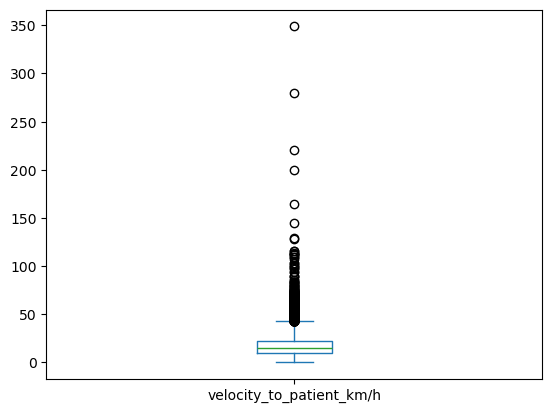

In [94]:
import matplotlib.pyplot as plt

df_dropped_na["velocity_to_patient_km/h"].plot(kind = "box")
# df_dropped_na["velocity_to_patient_km/h"].plot(kind = "bar")
plt.show()

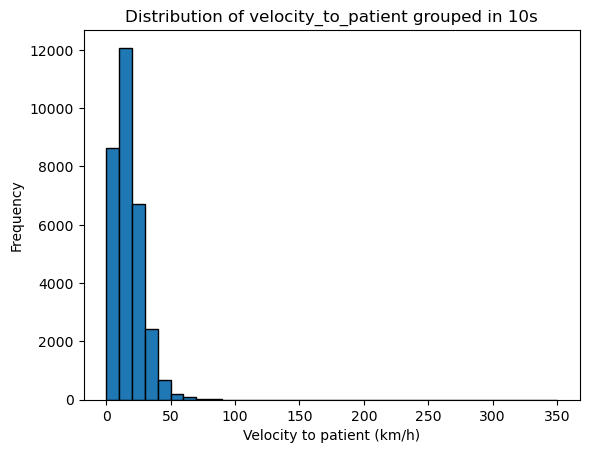

In [95]:
# Create bins of width 50 from 0 up to the max value
bins = range(0, int(df_dropped_na["velocity_to_patient_km/h"].max()) + 10, 10)

df_dropped_na["velocity_to_patient_km/h"].plot(kind="hist", bins=bins, edgecolor="black")

plt.xlabel("Velocity to patient (km/h)")
plt.ylabel("Frequency")
plt.title("Distribution of velocity_to_patient grouped in 10s")
plt.show()

Most of the velocities were between 0 to 50km/h